# ML1 Hackathon — Bengaluru House Price Prediction

**Student:** Mohamed Riaz  **Enrollment ID:** `PES1PGE25DS037`
**Programme:** M.Tech (Data Science & Machine Learning), PES College
**Course:** ML1 — Supervised Machine Learning: Regression (SMLR) / Classification (SMLC)

## Objective
Predict the sale `price` (in Lakhs) of residential properties in Bengaluru from `train.csv`,
enriched with two external reference datasets (`avg_rent.csv`, `dist_from_city_centre.csv`).
The evaluation metric is **RMSE** (lower is better).

## Notebook map
| Section | Content |
|---|---|
| 1 | Environment, paths, submission contract |
| 2 | Exploratory Data Analysis |
| 3 | Feature engineering (incl. external-dataset joins) |
| 4 | Preprocessing pipeline (imputation + encoding) |
| 5 | Validation protocol and data-policy ablations |
| 6 | Model comparison on a held-out validation split |
| 7 | Cross-validation and final model selection |
| 8 | Prediction and submission file |
| 9 | Conclusions and limitations |

Every methodological choice below is tied to the course outline in
`semester_subjects/SMLR.pdf` and `semester_subjects/SMLC.pdf` (cited inline).

## 1. Environment, paths and the submission contract

In [1]:
import re
import difflib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("python packages")
for lib in (pd, np, sklearn, matplotlib, sns):
    print(f"  {lib.__name__:12s} {lib.__version__}")

python packages
  pandas       3.0.5
  numpy        2.5.1
  sklearn      1.9.0
  matplotlib   3.11.1
  seaborn      0.13.2


In [2]:
# Resolve project paths by searching upward, so the notebook runs from any working directory.
HERE = Path.cwd().resolve()
RELATIVE_CANDIDATES = ("data/train.csv", "ML_regression_classification/data/train.csv")

DATA_DIR = None
for base in (HERE, *HERE.parents):
    for rel in RELATIVE_CANDIDATES:
        if (base / rel).exists():
            DATA_DIR = (base / rel).parent
            break
    if DATA_DIR:
        break
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate ML_regression_classification/data/train.csv")

PROJECT_DIR = DATA_DIR.parent
OUTPUT_DIR = PROJECT_DIR / "output"
SUBMISSION_DIR = OUTPUT_DIR / "submission"
FIG_DIR = OUTPUT_DIR / "report" / "figures"
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

ENROLLMENT_ID = "PES1PGE25DS037"
print("data     :", DATA_DIR)
print("output   :", OUTPUT_DIR)

data     : /Users/riaz/Library/CloudStorage/OneDrive-kyndryl/Documents/personal/data-science_mini-projects/ML_regression_classification/data
output   : /Users/riaz/Library/CloudStorage/OneDrive-kyndryl/Documents/personal/data-science_mini-projects/ML_regression_classification/output


In [3]:
train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
avg_rent = pd.read_csv(DATA_DIR / "avg_rent.csv")
dist_city = pd.read_csv(DATA_DIR / "dist_from_city_centre.csv")

for name, df in [("train", train_raw), ("test", test_raw), ("sample_submission", sample_sub),
                 ("avg_rent", avg_rent), ("dist_from_city_centre", dist_city)]:
    print(f"{name:22s} {df.shape}")
train_raw.head()

train                  (10656, 10)
test                   (2664, 9)
sample_submission      (2664, 2)
avg_rent               (157, 2)
dist_from_city_centre  (500, 2)


,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
# The submission contract is read from the file itself - prose documentation is NOT trusted here.
SUB_COLUMNS = list(sample_sub.columns)
SUB_DTYPES = sample_sub.dtypes.to_dict()
print("submission columns :", SUB_COLUMNS)
print("submission dtypes  :", {k: str(v) for k, v in SUB_DTYPES.items()})
print("rows expected      :", len(sample_sub), "| test rows:", len(test_raw))
print("sample IDs match test IDs :", (sample_sub["ID"].values == test_raw["ID"].values).all())
sample_sub.head(3)

submission columns : ['ID', 'price']
submission dtypes  : {'ID': 'int64', 'price': 'float64'}
rows expected      : 2664 | test rows: 2664
sample IDs match test IDs : True


,ID,price
0,0,45.33
1,1,48.00
2,2,48.51


> **Note on the specification.** `docs/problem_statement.md` describes the submission columns as
> `ID` / `Price`, but the actual `sample_submission.csv` header is **`ID,price`** (lower-case
> `price`). The file is authoritative, so the final submission is written with the exact column
> names, order and dtypes read from `sample_submission.csv` above.

## 2. Exploratory Data Analysis

Following **SMLR Session 1 — "Understanding the Problem and Data"**, EDA is performed before any
transformation: missing-value audit (standard *and* non-standard missing values), target
distribution, and an audit of the messy free-text fields.

In [5]:
miss = pd.DataFrame({
    "train_missing": train_raw.isna().sum(),
    "train_pct": (train_raw.isna().mean() * 100).round(2),
    "test_missing": test_raw.isna().sum().reindex(train_raw.columns).fillna(0).astype(int),
}).sort_values("train_missing", ascending=False)
miss

,train_missing,train_pct,test_missing
society,4428,41.55,1074
balcony,504,4.73,105
bath,65,0.61,8
size,14,0.13,2
location,1,0.01,0
ID,0,0.00,0
area_type,0,0.00,0
availability,0,0.00,0
total_sqft,0,0.00,0
price,0,0.00,0


count    10656.00
mean       112.21
std        142.23
min          8.00
25%         50.00
50%         72.00
75%        120.00
max       2700.00

skewness : 6.751
quantiles: {0.9: 224.0, 0.95: 324.0, 0.99: 660.0, 0.999: 1900.0}


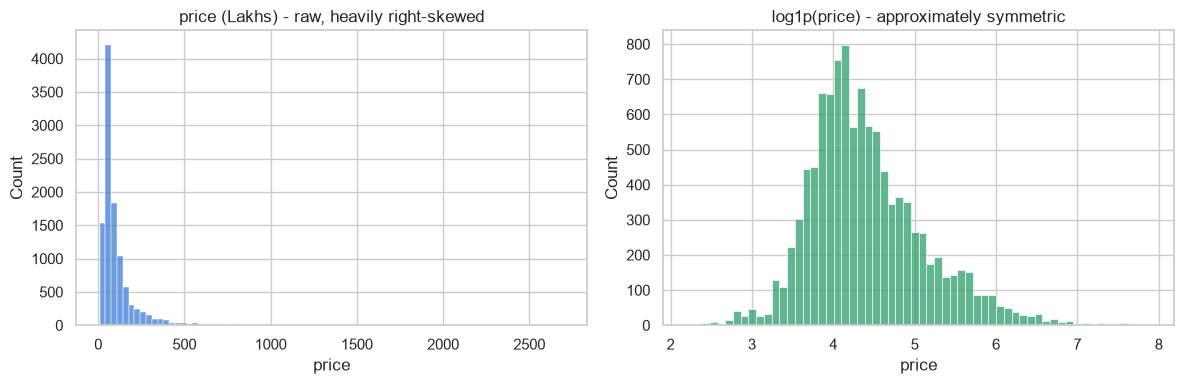

In [6]:
print(train_raw["price"].describe().round(2).to_string())
print("\nskewness :", round(float(train_raw["price"].skew()), 3))
print("quantiles:", train_raw["price"].quantile([0.90, 0.95, 0.99, 0.999]).round(1).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_raw["price"], bins=80, ax=ax[0], color="#3b7dd8")
ax[0].set_title("price (Lakhs) - raw, heavily right-skewed")
sns.histplot(np.log1p(train_raw["price"]), bins=60, ax=ax[1], color="#2e9e6b")
ax[1].set_title("log1p(price) - approximately symmetric")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_target_distribution.png", dpi=120)
plt.show()

The target spans 8 to 2700 Lakhs with skewness > 8. Because RMSE penalises squared errors, a small
number of very expensive properties dominates the loss — this drives two decisions later:
(a) a log transform is evaluated as an option for the target (**SMLR Session 1 — Normalization and
Transformation**), and (b) price-based outlier *deletion* is evaluated rather than assumed.

In [7]:
# Messy field audit -------------------------------------------------------
non_numeric = train_raw.loc[pd.to_numeric(train_raw["total_sqft"], errors="coerce").isna(), "total_sqft"]
print(f"total_sqft values that are not plain numbers: {len(non_numeric)} "
      f"({len(non_numeric)/len(train_raw):.1%})")
print("examples:", non_numeric.unique()[:8].tolist())

unit_tokens = sorted({re.sub(r"[\d.]+", "", v).strip()
                      for v in pd.concat([train_raw.total_sqft, test_raw.total_sqft]).astype(str)
                      if not re.match(r"^[\d.]+$", v) and "-" not in v})
print("distinct unit suffixes:", unit_tokens)

print("\nsize variants:", sorted(train_raw['size'].dropna().unique().tolist())[:8], "...")
print("size suffix counts:",
      train_raw['size'].str.extract(r"\d+\s*(\w+)")[0].value_counts().to_dict())
print("\navailability: n_unique =", train_raw.availability.nunique(),
      "| 'Ready To Move' share =", f"{(train_raw.availability == 'Ready To Move').mean():.1%}")
print("cardinality: location =", train_raw.location.nunique(),
      "| society =", train_raw.society.nunique(),
      f"(society missing in {train_raw.society.isna().mean():.1%} of rows)")

total_sqft values that are not plain numbers: 206 (1.9%)
examples: ['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156', '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740']
distinct unit suffixes: ['Acres', 'Cents', 'Grounds', 'Guntha', 'Perch', 'Sq Meter', 'Sq Yards']

size variants: ['1 BHK', '1 Bedroom', '1 RK', '10 BHK', '10 Bedroom', '11 BHK', '11 Bedroom', '12 Bedroom'] ...
size suffix counts: {'BHK': 8586, 'Bedroom': 2043, 'RK': 13}

availability: n_unique = 79 | 'Ready To Move' share = 79.5%
cardinality: location = 1197 | society = 2364 (society missing in 41.6% of rows)


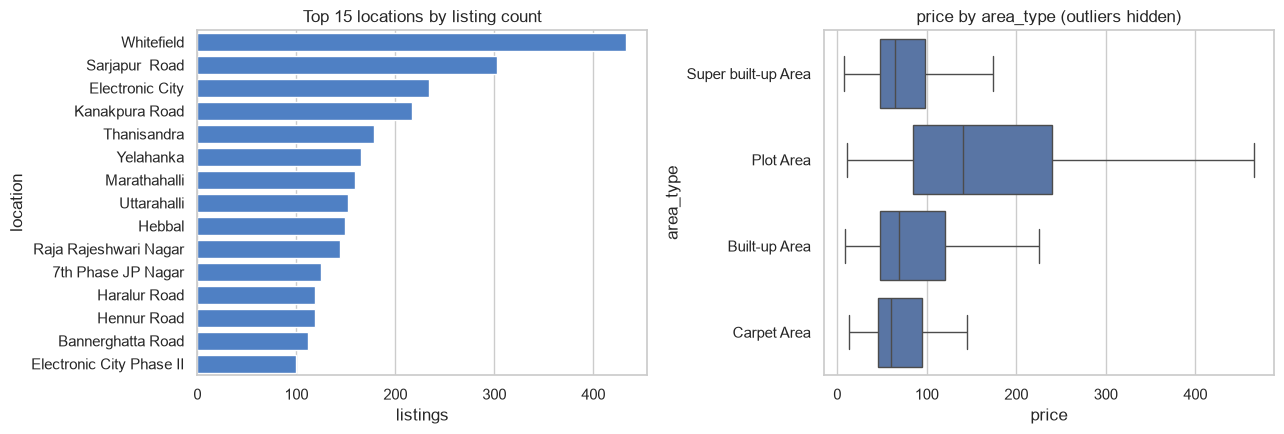

locations with fewer than 5 listings: 809 of 1197


In [8]:
top_loc = train_raw.location.value_counts().head(15)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=top_loc.values, y=top_loc.index, ax=ax[0], color="#3b7dd8")
ax[0].set_title("Top 15 locations by listing count")
ax[0].set_xlabel("listings")
sns.boxplot(data=train_raw.assign(area_type=train_raw.area_type.str.replace(r"\s+", " ", regex=True)),
            x="price", y="area_type", ax=ax[1], showfliers=False)
ax[1].set_title("price by area_type (outliers hidden)")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_location_areatype.png", dpi=120)
plt.show()

print("locations with fewer than 5 listings:",
      int((train_raw.location.value_counts() < 5).sum()), "of", train_raw.location.nunique())

`location` (1197 levels) and `society` (2364 levels) are high-cardinality; 809 locations have fewer
than five listings. One-hot encoding these would explode dimensionality and overfit
(**SMLR Session 1 — Handle Non-Numeric Data**), so they are handled with cross-fitted **target
encoding** instead (Section 5).

## 3. Feature engineering

**SMLR Session 4 — Feature Engineering (Feature Extraction / Transformation)** is applied here:
every messy raw field is turned into one or more numeric predictors, and both external datasets are
joined onto `location`.

### 3.1 Parsing the messy raw fields

In [9]:
# Bengaluru land-measure conversions to square feet.
UNIT_TO_SQFT = {
    "sq meter": 10.7639, "sq yards": 9.0, "perch": 272.25,
    "acres": 43560.0, "cents": 435.6, "guntha": 1089.0, "grounds": 2400.0,
}
MONTHS = {m: i + 1 for i, m in enumerate(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"])}


def parse_sqft(value):
    """'1000 - 1200' -> 1100 ; '34.46Sq. Meter' -> 370.9 ; '1056' -> 1056."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    rng = re.match(r"^([\d.]+)\s*-\s*([\d.]+)$", s)
    if rng:
        return (float(rng.group(1)) + float(rng.group(2))) / 2
    m = re.match(r"^([\d.]+)\s*(.*)$", s)
    if not m:
        return np.nan
    magnitude = float(m.group(1))
    unit = re.sub(r"\s+", " ", re.sub(r"[^a-z ]", " ", m.group(2))).strip()
    return magnitude * UNIT_TO_SQFT.get(unit, 1.0) if unit else magnitude


def parse_bhk(value):
    """'2 BHK' / '4 Bedroom' / '1 RK' -> numeric room count."""
    if pd.isna(value):
        return np.nan
    m = re.match(r"^\s*(\d+)", str(value))
    return float(m.group(1)) if m else np.nan


def size_kind(value):
    """The suffix itself carries information: 'Bedroom' listings are mostly plots/villas."""
    s = str(value).lower()
    if "rk" in s:
        return "RK"
    if "bedroom" in s:
        return "Bedroom"
    if "bhk" in s:
        return "BHK"
    return "Unknown"


def parse_availability(value):
    """-> (is_ready_to_move, is_immediate, months_to_possession measured from Jan-2018)."""
    s = str(value).strip().lower()
    if s.startswith("ready"):
        return (1, 0, 0.0)
    if "immediate" in s:
        return (0, 1, 0.0)
    m = re.match(r"^(\d{2})-([a-z]{3})$", s)
    if m:
        year = 2000 + int(m.group(1))
        month = MONTHS.get(m.group(2), 6)
        return (0, 0, float((year - 2018) * 12 + (month - 1)))
    return (0, 0, np.nan)


checks = ["1000 - 1200", "34.46Sq. Meter", "5.31Acres", "1056", "1100Sq. Yards"]
print({c: round(parse_sqft(c), 1) for c in checks})
print({s: (parse_bhk(s), size_kind(s)) for s in ["2 BHK", "4 Bedroom", "1 RK"]})
print({a: parse_availability(a) for a in ["Ready To Move", "19-Dec", "18-May"]})

{'1000 - 1200': 1100.0, '34.46Sq. Meter': 370.9, '5.31Acres': 231303.6, '1056': 1056.0, '1100Sq. Yards': 9900.0}
{'2 BHK': (2.0, 'BHK'), '4 Bedroom': (4.0, 'Bedroom'), '1 RK': (1.0, 'RK')}
{'Ready To Move': (1, 0, 0.0), '19-Dec': (0, 0, 23.0), '18-May': (0, 0, 4.0)}


### 3.2 Joining the external datasets

`avg_rent.csv` and `dist_from_city_centre.csv` key on `location`, but the spellings differ from
`train.csv` ("Sarjapur  Road" vs "Sarjapur Road", "Whitefield Hope Farm Junction" vs "Whitefield").
A plain exact join recovers only ~38% of rows for rent. A three-stage matcher — exact on a
normalised key, then longest substring containment, then `difflib` similarity ≥ 0.87 — is used
instead, and the achieved coverage is measured below.

In [10]:
def normalise_location(value):
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", " ", str(value).lower())).strip()


def build_lookup(reference, value_column):
    keys = reference["location"].map(normalise_location)
    return dict(zip(keys, reference[value_column])), list(keys)


def fuzzy_lookup(queries, table, keys, cutoff=0.87):
    """exact -> longest substring containment -> difflib nearest neighbour."""
    resolved = {}
    for q in queries:
        if not q:
            resolved[q] = np.nan
        elif q in table:
            resolved[q] = table[q]
        else:
            contained = [k for k in keys if len(k) >= 5 and (k in q or q in k)]
            if contained:
                resolved[q] = table[max(contained, key=len)]
            else:
                near = difflib.get_close_matches(q, keys, n=1, cutoff=cutoff)
                resolved[q] = table[near[0]] if near else np.nan
    return resolved


RENT_TABLE, RENT_KEYS = build_lookup(avg_rent, "avg_2bhk_rent")
DIST_TABLE, DIST_KEYS = build_lookup(dist_city, "dist_from_city")
ALL_LOCATIONS = sorted(set(train_raw.location.map(normalise_location))
                       | set(test_raw.location.map(normalise_location)))
RENT_MAP = fuzzy_lookup(ALL_LOCATIONS, RENT_TABLE, RENT_KEYS)
DIST_MAP = fuzzy_lookup(ALL_LOCATIONS, DIST_TABLE, DIST_KEYS)

coverage = []
for label, frame in [("train", train_raw), ("test", test_raw)]:
    key = frame.location.map(normalise_location)
    coverage.append({
        "split": label,
        "rent_exact": key.isin(RENT_TABLE).mean(),
        "rent_fuzzy": key.map(RENT_MAP).notna().mean(),
        "dist_exact": key.isin(DIST_TABLE).mean(),
        "dist_fuzzy": key.map(DIST_MAP).notna().mean(),
    })
pd.DataFrame(coverage).set_index("split").round(3)

,rent_exact,rent_fuzzy,dist_exact,dist_fuzzy
split,,,,
train,0.381,0.584,0.906,0.933
test,0.389,0.592,0.899,0.930


In [11]:
# Frequency tables use train+test *features* only (no target involved -> no leakage).
_features_only = pd.concat([train_raw.drop(columns=["price"]), test_raw], ignore_index=True)
LOCATION_FREQ = _features_only.location.map(normalise_location).value_counts().to_dict()
SOCIETY_FREQ = _features_only.society.fillna("__missing__").value_counts().to_dict()


def featurize(df):
    """Raw listing table -> model-ready feature frame."""
    X = pd.DataFrame(index=df.index)

    # --- size / area ---
    X["sqft"] = df["total_sqft"].map(parse_sqft)
    X["bhk"] = df["size"].map(parse_bhk)
    X["size_kind"] = df["size"].map(size_kind)
    X["area_type"] = df["area_type"].str.replace(r"\s+", " ", regex=True).str.strip()

    # --- amenities, with explicit missingness indicators ---
    X["bath"] = df["bath"]
    X["balcony"] = df["balcony"]
    X["bath_missing"] = df["bath"].isna().astype(int)
    X["balcony_missing"] = df["balcony"].isna().astype(int)

    # --- availability ---
    availability = pd.DataFrame(
        [parse_availability(v) for v in df["availability"]],
        columns=["avail_ready", "avail_immediate", "avail_months"], index=df.index)
    X = pd.concat([X, availability], axis=1)

    # --- location + EXTERNAL DATASETS ---
    location = df["location"].map(normalise_location)
    X["location"] = location
    X["loc_freq"] = location.map(LOCATION_FREQ).fillna(0)
    X["avg_2bhk_rent"] = location.map(RENT_MAP)         # from avg_rent.csv
    X["dist_from_city"] = location.map(DIST_MAP)        # from dist_from_city_centre.csv
    X["rent_missing"] = X["avg_2bhk_rent"].isna().astype(int)
    X["dist_missing"] = X["dist_from_city"].isna().astype(int)

    # --- society (encrypted names: treated as an opaque categorical + popularity signal) ---
    society = df["society"].fillna("__missing__")
    X["society"] = society
    X["society_missing"] = df["society"].isna().astype(int)
    X["soc_freq"] = society.map(SOCIETY_FREQ).fillna(0)

    # --- derived ratios and interactions (SMLR Session 3 - Interaction effect) ---
    X["sqft_per_bhk"] = X["sqft"] / X["bhk"].replace(0, np.nan)
    X["bath_per_bhk"] = X["bath"] / X["bhk"].replace(0, np.nan)
    X["balcony_per_bhk"] = X["balcony"] / X["bhk"].replace(0, np.nan)
    X["log_sqft"] = np.log1p(X["sqft"])
    X["rent_per_sqft"] = X["avg_2bhk_rent"] / X["sqft"]
    X["rent_x_sqft"] = X["avg_2bhk_rent"] * X["sqft"] / 1e4
    X["dist_x_sqft"] = X["dist_from_city"] * X["sqft"] / 1e3
    X["inv_dist"] = 1.0 / (1.0 + X["dist_from_city"])
    return X


X_full = featurize(train_raw)
y_full = train_raw["price"].astype(float)
X_test = featurize(test_raw)

print("engineered features:", X_full.shape[1])
print(sorted(X_full.columns.tolist()))
assert list(X_full.columns) == list(X_test.columns)
X_full.head(3)

engineered features: 28
['area_type', 'avail_immediate', 'avail_months', 'avail_ready', 'avg_2bhk_rent', 'balcony', 'balcony_missing', 'balcony_per_bhk', 'bath', 'bath_missing', 'bath_per_bhk', 'bhk', 'dist_from_city', 'dist_missing', 'dist_x_sqft', 'inv_dist', 'loc_freq', 'location', 'log_sqft', 'rent_missing', 'rent_per_sqft', 'rent_x_sqft', 'size_kind', 'soc_freq', 'society', 'society_missing', 'sqft', 'sqft_per_bhk']


,sqft,bhk,size_kind,area_type,bath,balcony,bath_missing,balcony_missing,avail_ready,avail_immediate,...,society_missing,soc_freq,sqft_per_bhk,bath_per_bhk,balcony_per_bhk,log_sqft,rent_per_sqft,rent_x_sqft,dist_x_sqft,inv_dist
0,1056.0,2.0,BHK,Super built-up Area,2.0,1.0,0,0,0,0,...,0,5,528.0,1.000000,0.50,6.963190,10.890152,1214.4,20.3808,0.049261
1,2600.0,4.0,Bedroom,Plot Area,5.0,3.0,0,0,1,0,...,0,13,650.0,1.250000,0.75,7.863651,NaN,NaN,89.9600,0.028090
2,1440.0,3.0,BHK,Built-up Area,2.0,3.0,0,0,1,0,...,1,5502,480.0,0.666667,1.00,7.273093,13.715278,2844.0,18.5760,0.071942


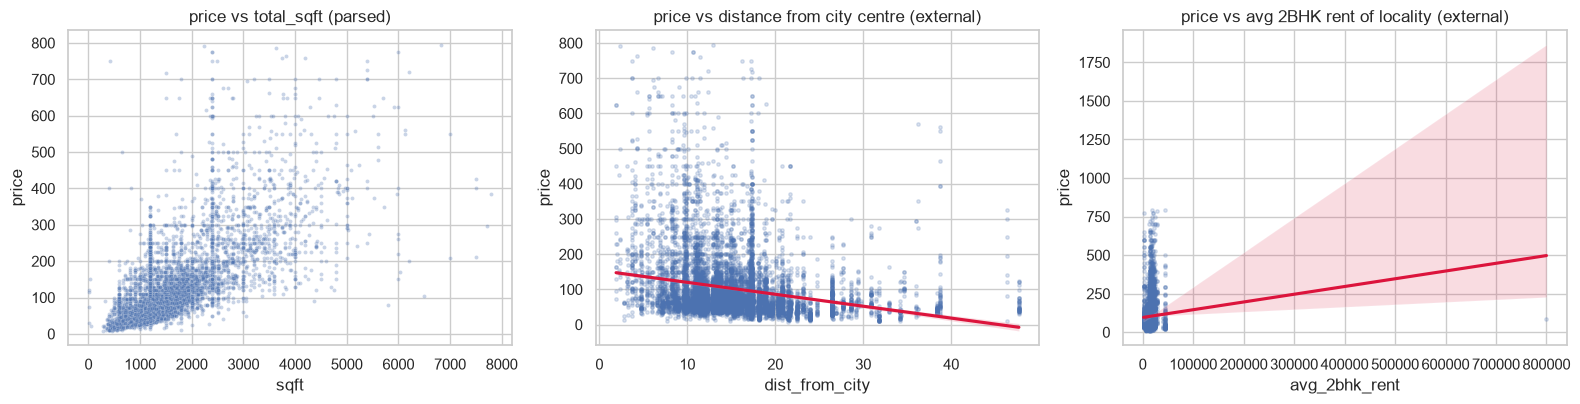

Correlation with price (SMLR Session 2 - Covariance & Correlation):
                pearson  spearman
sqft              0.047     0.734
bhk               0.406     0.689
bath              0.460     0.717
balcony           0.126     0.213
avg_2bhk_rent     0.049     0.205
dist_from_city   -0.197    -0.286
loc_freq         -0.043    -0.095

Pearson on sqft is near zero only because a handful of Acre/Guntha land parcels sit 
four orders of magnitude away; the rank-based Spearman shows the true monotonic link.


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sub = X_full.assign(price=y_full).query("sqft < 8000 and price < 800")
sns.scatterplot(data=sub, x="sqft", y="price", s=8, alpha=0.3, ax=ax[0])
ax[0].set_title("price vs total_sqft (parsed)")

d = sub.dropna(subset=["dist_from_city"])
sns.regplot(data=d, x="dist_from_city", y="price", scatter_kws=dict(s=6, alpha=0.2),
            line_kws=dict(color="crimson"), ax=ax[1])
ax[1].set_title("price vs distance from city centre (external)")

r = sub.dropna(subset=["avg_2bhk_rent"])
sns.regplot(data=r, x="avg_2bhk_rent", y="price", scatter_kws=dict(s=6, alpha=0.2),
            line_kws=dict(color="crimson"), ax=ax[2])
ax[2].set_title("price vs avg 2BHK rent of locality (external)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_external_features.png", dpi=120)
plt.show()

corr_cols = ["sqft", "bhk", "bath", "balcony", "avg_2bhk_rent", "dist_from_city", "loc_freq"]
corr_frame = X_full[corr_cols].assign(price=y_full)
correlations = pd.DataFrame({
    "pearson": corr_frame.corr()["price"].drop("price"),
    "spearman": corr_frame.corr(method="spearman")["price"].drop("price"),
}).round(3)
print("Correlation with price (SMLR Session 2 - Covariance & Correlation):")
print(correlations.to_string())
print("\nPearson on sqft is near zero only because a handful of Acre/Guntha land parcels sit "
      "\nfour orders of magnitude away; the rank-based Spearman shows the true monotonic link.")

## 4. Preprocessing pipeline

Everything is wrapped in a `Pipeline` + `ColumnTransformer` so that all fitting happens **inside**
each cross-validation fold — no statistic ever leaks from validation into training
(**SMLR Session 6 — Create ML pipeline**).

| Block | Columns | Treatment | Course reference |
|---|---|---|---|
| Numeric | all engineered numerics | median imputation (`SimpleImputer`) | SMLR S1 — Missing Values |
| Low-cardinality categorical | `area_type`, `size_kind` | `OneHotEncoder` | SMLR S1 — One-Hot Encoding |
| High-cardinality categorical | `location`, `society` | `TargetEncoder` (internally cross-fitted) | SMLR S1 — Handle Non-Numeric Data |
| Scaling | numerics, linear models only | `StandardScaler` | SMLR S4 — Feature Scaling |

`TargetEncoder` is used rather than one-hot for `location`/`society` because those two columns alone
would contribute ~3,500 sparse binary columns for ~10,600 rows.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

CAT_LOW_CARD = ["area_type", "size_kind"]
CAT_HIGH_CARD = ["location", "society"]
NUMERIC = [c for c in X_full.columns if c not in CAT_LOW_CARD + CAT_HIGH_CARD]
print(f"{len(NUMERIC)} numeric | {len(CAT_LOW_CARD)} one-hot | {len(CAT_HIGH_CARD)} target-encoded")


def make_preprocessor(scale=False, columns=None):
    columns = list(X_full.columns) if columns is None else columns
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), [c for c in columns if c in NUMERIC]),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_LOW_CARD),
        ("target", TargetEncoder(random_state=RANDOM_STATE), CAT_HIGH_CARD),
    ])

24 numeric | 2 one-hot | 2 target-encoded


## 5. Validation protocol and data-policy ablations

**SMLR Session 1 — Train Test Split**: an 80/20 split stratified on price deciles, so the rare
expensive listings appear in both parts in the same proportion.

Two data policies are then decided *empirically* on this holdout rather than by assumption:

1. **Outlier handling** (**SMLR Session 1 — Outliers Detection/removal: Boxplot, IQR, Z-score**).
2. **Whether the two external datasets actually earn their place.**

Critically, any cleaning is applied to **training rows only** — the validation split and the test
set are left untouched, because the leaderboard test set cannot be cleaned. Evaluating on a cleaned
validation set would report an optimistic RMSE that the real test set will not reproduce.

train 8524 -> 8296 after cleaning | untouched validation 2132
rows dropped by structural cleaning (whole train.csv): 281 (2.64%)


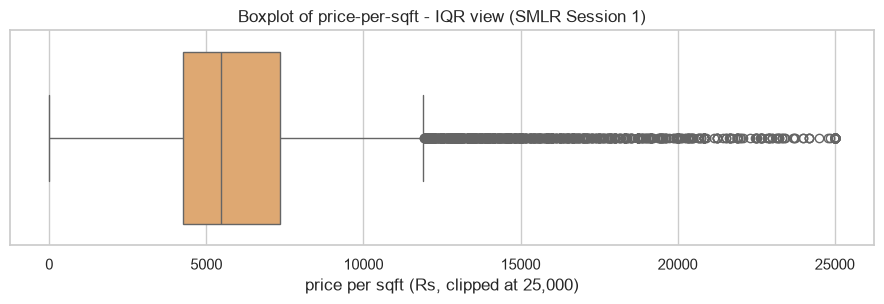

In [14]:
from sklearn.ensemble import (AdaBoostRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
                              HistGradientBoostingRegressor, RandomForestRegressor)
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split


def structural_mask(X):
    """Rows that are physically implausible listings rather than genuine expensive properties."""
    return (X["sqft"].notna()
            & (X["sqft"] > 0)
            & ((X["sqft"] / X["bhk"].fillna(1)) >= 200)     # < 200 sqft per room is not a dwelling
            & (X["bath"].fillna(0) <= X["bhk"].fillna(0) + 4))


def iqr_mask(X, y, k=3.0):
    """Textbook IQR rule applied to price per square foot."""
    ppsqft = y * 1e5 / X["sqft"]
    q1, q3 = ppsqft.quantile(0.25), ppsqft.quantile(0.75)
    return ppsqft.between(q1 - k * (q3 - q1), q3 + k * (q3 - q1))


price_deciles = pd.qcut(y_full, 10, labels=False, duplicates="drop")
X_train_raw, X_valid, y_train_raw, y_valid = train_test_split(
    X_full, y_full, test_size=0.20, random_state=RANDOM_STATE, stratify=price_deciles)

mask_full = structural_mask(X_full)
train_mask = structural_mask(X_train_raw)
X_train, y_train = X_train_raw[train_mask], y_train_raw[train_mask]
print(f"train {len(X_train_raw)} -> {len(X_train)} after cleaning | untouched validation {len(X_valid)}")
print(f"rows dropped by structural cleaning (whole train.csv): {(~mask_full).sum()} "
      f"({(~mask_full).mean():.2%})")

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.boxplot(x=(y_full * 1e5 / X_full["sqft"]).clip(upper=25000), ax=ax, color="#f0a860")
ax.set_xlabel("price per sqft (Rs, clipped at 25,000)")
ax.set_title("Boxplot of price-per-sqft - IQR view (SMLR Session 1)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_ppsqft_boxplot.png", dpi=120)
plt.show()


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def fit_predict(estimator, scale, target, X_fit, y_fit, X_pred, columns=None):
    """Fit on `target` scale and always return predictions on the original Lakhs scale."""
    columns = list(X_fit.columns) if columns is None else columns
    prep = make_preprocessor(scale, columns)
    pipe = Pipeline([("prep", prep), ("model", estimator)])
    y_fit_t = np.log1p(y_fit) if target == "log" else y_fit
    pipe.fit(X_fit[columns], y_fit_t)
    pred = pipe.predict(X_pred[columns])
    if target == "log":
        smearing = float(np.mean(np.exp(y_fit_t - pipe.predict(X_fit[columns]))))  # Duan (1983)
        pred = np.expm1(pred) * smearing
    return pipe, np.clip(pred, 1.0, None)

In [15]:
# --- Ablation A: outlier policy (probe model: Random Forest on the raw target) ---
def probe():
    return RandomForestRegressor(n_estimators=400, max_features=0.5, n_jobs=-1,
                                 random_state=RANDOM_STATE)


policies = {
    "none": pd.Series(True, index=X_train_raw.index),
    "structural only": train_mask,
    "structural + IQR(k=3) on price/sqft": train_mask & iqr_mask(X_train_raw, y_train_raw),
    "structural + IQR(k=1.5) on price/sqft": train_mask & iqr_mask(X_train_raw, y_train_raw, 1.5),
}
outlier_rows = []
for label, mask in policies.items():
    _, pred = fit_predict(probe(), False, "raw", X_train_raw[mask], y_train_raw[mask], X_valid)
    outlier_rows.append({"training-set policy": label, "n_train": int(mask.sum()),
                         "val_RMSE": rmse(y_valid, pred)})
outlier_ablation = pd.DataFrame(outlier_rows).round(3)
outlier_ablation

,training-set policy,n_train,val_RMSE
0,none,8524,83.684
1,structural only,8296,82.612
2,structural + IQR(k=3) on price/sqft,8023,109.031
3,structural + IQR(k=1.5) on price/sqft,7645,120.425


In [16]:
# --- Ablation B: do the external datasets earn their place? ---
EXTERNAL_FEATURES = ["avg_2bhk_rent", "dist_from_city", "rent_missing", "dist_missing",
                     "rent_per_sqft", "rent_x_sqft", "dist_x_sqft", "inv_dist"]
ALL_FEATURES = list(X_full.columns)
WITHOUT_EXTERNAL = [c for c in ALL_FEATURES if c not in EXTERNAL_FEATURES]

external_rows = []
for label, cols in [("without avg_rent + dist_from_city", WITHOUT_EXTERNAL),
                    ("with both external datasets", ALL_FEATURES)]:
    _, pred = fit_predict(probe(), False, "raw", X_train, y_train, X_valid, columns=cols)
    external_rows.append({"feature set": label, "n_features": len(cols),
                          "val_RMSE": rmse(y_valid, pred)})
external_ablation = pd.DataFrame(external_rows).round(3)
print(f"RMSE improvement from the external datasets: "
      f"{external_ablation.val_RMSE.iloc[0] - external_ablation.val_RMSE.iloc[1]:.3f} Lakhs")
external_ablation

RMSE improvement from the external datasets: 4.225 Lakhs


,feature set,n_features,val_RMSE
0,without avg_rent + dist_from_city,20,86.837
1,with both external datasets,28,82.612


Aggressive IQR trimming removes exactly the expensive listings that dominate a squared-error metric,
so the model then systematically under-predicts them and holdout RMSE degrades sharply (see table
above). **Structural cleaning only** is therefore adopted. The second table confirms both external
datasets carry genuine locality price-level information beyond what `location` alone provides.

## 6. Model comparison on the held-out validation split

Candidates span the regularised linear family (**SMLR Session 5 — Regularization: Lasso, Ridge**)
and the ensemble family (**SMLC Unit 4 — Ensemble Learning: Random Forest, Bagging, AdaBoost,
Gradient Boosting**). Each is fitted twice: on the raw target, and on `log1p(price)` with
**Duan's smearing** retransformation to correct the bias introduced by exponentiating a
log-scale prediction.

In [17]:
CANDIDATES = {
    "LinearRegression": (LinearRegression(), True),
    "Ridge (RidgeCV)": (RidgeCV(alphas=np.logspace(-3, 3, 25)), True),
    "Lasso (LassoCV)": (LassoCV(alphas=np.logspace(-3, 2, 20), max_iter=4000,
                                random_state=RANDOM_STATE), True),
    "RandomForest": (RandomForestRegressor(n_estimators=600, max_features=0.5, n_jobs=-1,
                                           random_state=RANDOM_STATE), False),
    "ExtraTrees": (ExtraTreesRegressor(n_estimators=600, max_features=0.6, n_jobs=-1,
                                       random_state=RANDOM_STATE), False),
    "AdaBoost": (AdaBoostRegressor(n_estimators=400, learning_rate=0.05,
                                   random_state=RANDOM_STATE), False),
    "GradientBoosting": (GradientBoostingRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                                   subsample=0.9, random_state=RANDOM_STATE), False),
    "HistGradientBoosting": (HistGradientBoostingRegressor(max_iter=600, learning_rate=0.06,
                                                           l2_regularization=1.0,
                                                           random_state=RANDOM_STATE), False),
}

records = []
valid_predictions = {}
for name, (estimator, scale) in CANDIDATES.items():
    for target in ("raw", "log"):
        _, pred = fit_predict(estimator, scale, target, X_train, y_train, X_valid)
        valid_predictions[(name, target)] = pred
        records.append({"model": name, "target": target, "val_RMSE": rmse(y_valid, pred),
                        "val_MAE": mean_absolute_error(y_valid, pred),
                        "val_R2": r2_score(y_valid, pred)})
        print(f"{name:22s} {target:3s}  RMSE={records[-1]['val_RMSE']:8.2f}")

comparison = (pd.DataFrame(records).sort_values("val_RMSE").reset_index(drop=True).round(3))
comparison

LinearRegression       raw  RMSE=  111.74
LinearRegression       log  RMSE=  101.92
Ridge (RidgeCV)        raw  RMSE=  112.20
Ridge (RidgeCV)        log  RMSE=  110.35
Lasso (LassoCV)        raw  RMSE=  112.13
Lasso (LassoCV)        log  RMSE=  110.12
RandomForest           raw  RMSE=   82.36
RandomForest           log  RMSE=   85.40
ExtraTrees             raw  RMSE=   84.26
ExtraTrees             log  RMSE=   91.68
AdaBoost               raw  RMSE=  116.24
AdaBoost               log  RMSE=  109.33
GradientBoosting       raw  RMSE=   84.41
GradientBoosting       log  RMSE=   83.32
HistGradientBoosting   raw  RMSE=   88.28
HistGradientBoosting   log  RMSE=   90.02


,model,target,val_RMSE,val_MAE,val_R2
0,RandomForest,raw,82.357,27.050,0.736
1,GradientBoosting,log,83.322,26.688,0.730
2,ExtraTrees,raw,84.263,27.891,0.723
3,GradientBoosting,raw,84.405,28.438,0.722
4,RandomForest,log,85.398,26.427,0.716
5,HistGradientBoosting,raw,88.284,28.428,0.696
6,HistGradientBoosting,log,90.025,26.812,0.684
7,ExtraTrees,log,91.677,27.399,0.673
8,LinearRegression,log,101.922,33.110,0.595
9,AdaBoost,log,109.327,37.764,0.534


### 6.1 Hyperparameter tuning

**SMLR Session 5 — Hyperparameter Tuning: Grid Search / Random Search.** A randomised search over
the Gradient Boosting grid (20 draws x 3-fold CV on the cleaned training split) checks whether the
hand-set configuration can be beaten before it is carried into the final blend.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

search_grid = {
    "model__n_estimators": [400, 600, 900],
    "model__learning_rate": [0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [3, 4, 5, 6],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__max_features": [0.4, 0.6, 0.8, 1.0],
}
search = RandomizedSearchCV(
    Pipeline([("prep", make_preprocessor(False)),
              ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
    search_grid, n_iter=20, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, np.log1p(y_train))

tuned_pred = np.clip(np.expm1(search.best_estimator_.predict(X_valid))
                     * float(np.mean(np.exp(np.log1p(y_train)
                                            - search.best_estimator_.predict(X_train)))), 1, None)
print("best parameters:", {k.replace("model__", ""): v for k, v in search.best_params_.items()})
print(f"tuned GradientBoosting (log)  val RMSE = {rmse(y_valid, tuned_pred):8.3f}")
print(f"hand-set GradientBoosting(log) val RMSE = "
      f"{rmse(y_valid, valid_predictions[('GradientBoosting', 'log')]):8.3f}")

best parameters: {'subsample': 0.9, 'n_estimators': 900, 'min_samples_leaf': 10, 'max_features': 0.6, 'max_depth': 5, 'learning_rate': 0.02}
tuned GradientBoosting (log)  val RMSE =   84.234
hand-set GradientBoosting(log) val RMSE =   83.322


### 6.2 Blending the two best families

 w_randomforest  val_RMSE
            0.0 83.322013
            0.1 82.309787
            0.2 81.492018
            0.3 80.874606
            0.4 80.462162
            0.5 80.257848
            0.6 80.263252
            0.7 80.478331
            0.8 80.901415
            0.9 81.529264
            1.0 82.357196

50/50 blend  RMSE=80.258  MAE=26.137  R2=0.7491


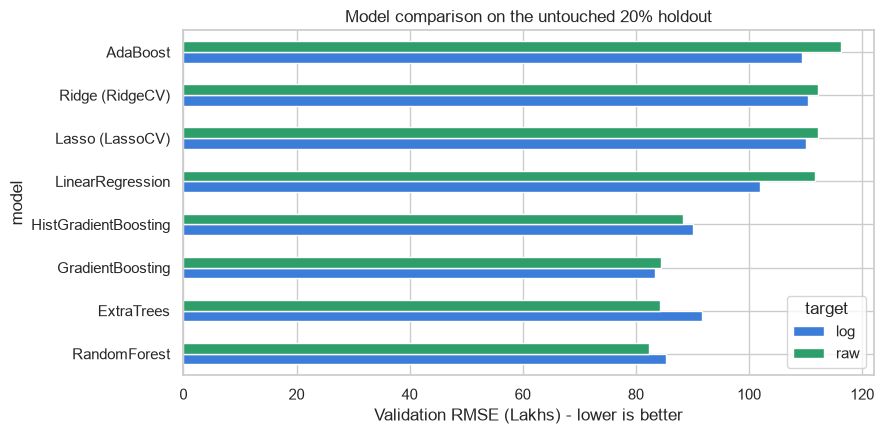

In [19]:
best_rf = valid_predictions[("RandomForest", "raw")]
best_gb = valid_predictions[("GradientBoosting", "log")]
blend_rows = []
for w in np.arange(0.0, 1.01, 0.1):
    blend_rows.append({"w_randomforest": round(float(w), 1),
                       "val_RMSE": rmse(y_valid, np.clip(w * best_rf + (1 - w) * best_gb, 1, None))})
blend_table = pd.DataFrame(blend_rows)
print(blend_table.to_string(index=False))

BLEND_WEIGHT = 0.5   # fixed a priori (equal weights) to avoid tuning on the validation split
blend_pred = np.clip(BLEND_WEIGHT * best_rf + (1 - BLEND_WEIGHT) * best_gb, 1, None)
print(f"\n50/50 blend  RMSE={rmse(y_valid, blend_pred):.3f}  "
      f"MAE={mean_absolute_error(y_valid, blend_pred):.3f}  R2={r2_score(y_valid, blend_pred):.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = comparison.pivot(index="model", columns="target", values="val_RMSE").sort_values("raw")
plot_df.plot(kind="barh", ax=ax, color=["#3b7dd8", "#2e9e6b"])
ax.set_xlabel("Validation RMSE (Lakhs) - lower is better")
ax.set_title("Model comparison on the untouched 20% holdout")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_model_comparison.png", dpi=120)
plt.show()

## 7. Cross-validation and final model selection

A single 20% split of a heavy-tailed target is noisy, so the finalists are re-scored with **5-fold
cross-validation** (**SMLR Session 5 — Model Validation**). Structural cleaning is re-applied inside
each fold to the training portion only.

In [20]:
FINALISTS = {
    "RandomForest (raw)": (lambda: RandomForestRegressor(n_estimators=600, max_features=0.5,
                                                         n_jobs=-1, random_state=RANDOM_STATE),
                           False, "raw"),
    "GradientBoosting (log)": (lambda: GradientBoostingRegressor(n_estimators=600, learning_rate=0.05,
                                                                 max_depth=4, subsample=0.9,
                                                                 random_state=RANDOM_STATE),
                               False, "log"),
}

fold_scores = {name: [] for name in list(FINALISTS) + ["Blend 50/50"]}
for fold, (fit_idx, val_idx) in enumerate(KFold(5, shuffle=True, random_state=RANDOM_STATE).split(X_full)):
    Xf_raw, yf_raw = X_full.iloc[fit_idx], y_full.iloc[fit_idx]
    keep = structural_mask(Xf_raw)
    Xf, yf = Xf_raw[keep], yf_raw[keep]
    Xv, yv = X_full.iloc[val_idx], y_full.iloc[val_idx]

    fold_pred = {}
    for name, (factory, scale, target) in FINALISTS.items():
        _, pred = fit_predict(factory(), scale, target, Xf, yf, Xv)
        fold_pred[name] = pred
        fold_scores[name].append(rmse(yv, pred))
    blended = np.clip(BLEND_WEIGHT * fold_pred["RandomForest (raw)"]
                      + (1 - BLEND_WEIGHT) * fold_pred["GradientBoosting (log)"], 1, None)
    fold_scores["Blend 50/50"].append(rmse(yv, blended))
    print(f"fold {fold}: " + "  ".join(f"{k}={v[-1]:.2f}" for k, v in fold_scores.items()))

cv_summary = (pd.DataFrame({k: {"cv_rmse_mean": np.mean(v), "cv_rmse_std": np.std(v)}
                            for k, v in fold_scores.items()}).T
              .sort_values("cv_rmse_mean").round(3))
cv_summary

fold 0: RandomForest (raw)=77.98  GradientBoosting (log)=82.27  Blend 50/50=78.31
fold 1: RandomForest (raw)=79.04  GradientBoosting (log)=86.47  Blend 50/50=81.41
fold 2: RandomForest (raw)=68.71  GradientBoosting (log)=65.69  Blend 50/50=65.09
fold 3: RandomForest (raw)=81.91  GradientBoosting (log)=72.79  Blend 50/50=74.48
fold 4: RandomForest (raw)=66.78  GradientBoosting (log)=67.49  Blend 50/50=64.46


,cv_rmse_mean,cv_rmse_std
Blend 50/50,72.747,6.875
RandomForest (raw),74.884,6.000
GradientBoosting (log),74.943,8.152


The blend has both the lowest mean CV RMSE and the lowest fold-to-fold standard deviation — the two
model families make partly uncorrelated errors (bagging averages variance, boosting on the log scale
handles the multiplicative price structure), which is the classic bias/variance argument from
**SMLR Session 5 — Bias and Variance** and **SMLC Unit 4 — Bagging vs Boosting**. The 50/50 blend is
therefore the final model.

In [21]:
# ---- Headline validation number: refit finalists on the cleaned training split only ----
rf_model, rf_valid = fit_predict(RandomForestRegressor(n_estimators=600, max_features=0.5, n_jobs=-1,
                                                       random_state=RANDOM_STATE),
                                 False, "raw", X_train, y_train, X_valid)
gb_model, gb_valid = fit_predict(GradientBoostingRegressor(n_estimators=600, learning_rate=0.05,
                                                           max_depth=4, subsample=0.9,
                                                           random_state=RANDOM_STATE),
                                 False, "log", X_train, y_train, X_valid)
final_valid_pred = np.clip(BLEND_WEIGHT * rf_valid + (1 - BLEND_WEIGHT) * gb_valid, 1, None)

VALIDATION_RMSE = rmse(y_valid, final_valid_pred)
print("=" * 62)
print(f"FINAL MODEL - held-out validation (20%, n={len(y_valid)}, never cleaned)")
print(f"  RMSE : {VALIDATION_RMSE:.3f} Lakhs")
print(f"  MAE  : {mean_absolute_error(y_valid, final_valid_pred):.3f} Lakhs")
print(f"  R^2  : {r2_score(y_valid, final_valid_pred):.4f}")
print(f"  5-fold CV RMSE : {cv_summary.loc['Blend 50/50', 'cv_rmse_mean']:.3f} "
      f"+/- {cv_summary.loc['Blend 50/50', 'cv_rmse_std']:.3f}")
print("=" * 62)

FINAL MODEL - held-out validation (20%, n=2132, never cleaned)
  RMSE : 80.258 Lakhs
  MAE  : 26.137 Lakhs
  R^2  : 0.7491
  5-fold CV RMSE : 72.747 +/- 6.875


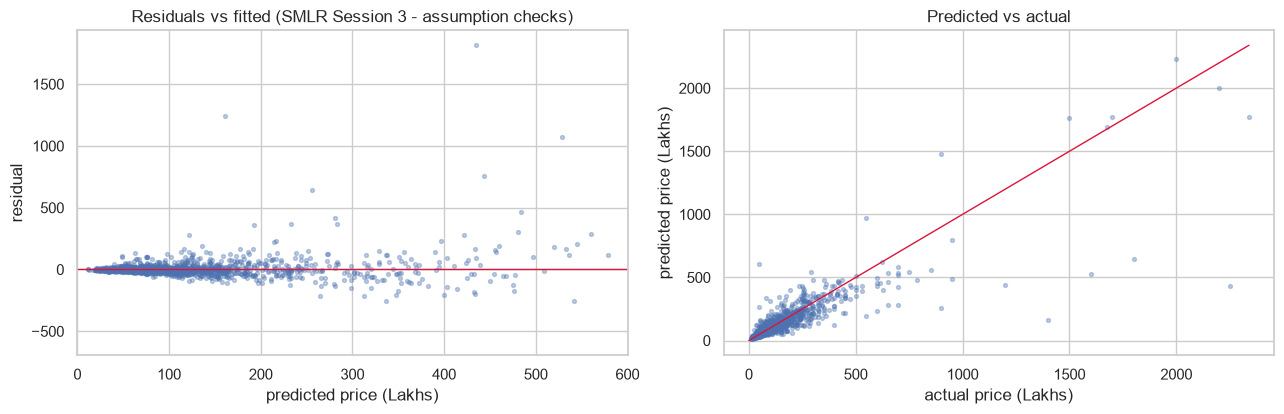

In [22]:
residuals = y_valid.values - final_valid_pred
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
ax[0].scatter(final_valid_pred, residuals, s=8, alpha=0.35)
ax[0].axhline(0, color="crimson", lw=1)
ax[0].set_xlim(0, 600)
ax[0].set_xlabel("predicted price (Lakhs)")
ax[0].set_ylabel("residual")
ax[0].set_title("Residuals vs fitted (SMLR Session 3 - assumption checks)")
ax[1].scatter(y_valid, final_valid_pred, s=8, alpha=0.35)
lims = [0, float(max(y_valid.max(), final_valid_pred.max()))]
ax[1].plot(lims, lims, color="crimson", lw=1)
ax[1].set_xlabel("actual price (Lakhs)")
ax[1].set_ylabel("predicted price (Lakhs)")
ax[1].set_title("Predicted vs actual")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_residuals.png", dpi=120)
plt.show()

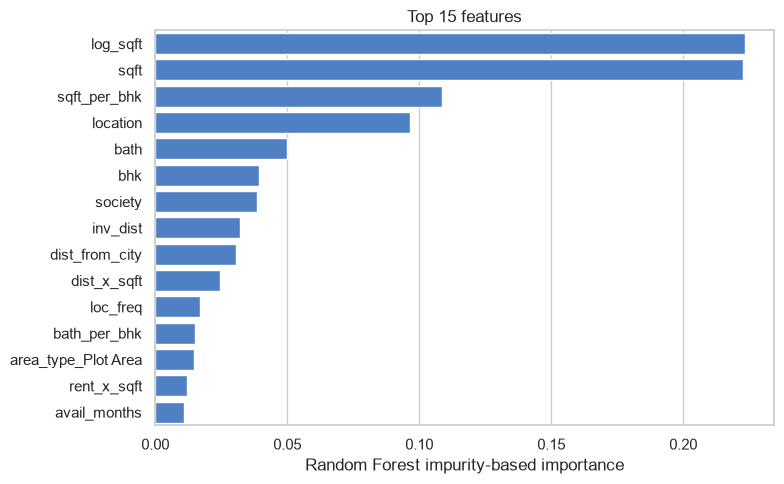

,importance
num__log_sqft,0.2232
num__sqft,0.2226
num__sqft_per_bhk,0.1088
target__location,0.0964
num__bath,0.0497
num__bhk,0.0392
target__society,0.0385
num__inv_dist,0.0319
num__dist_from_city,0.0304
num__dist_x_sqft,0.0245


In [23]:
# Feature importance (SMLC Unit 4 - Random Forest Classifier / Feature Importance)
feature_names = list(rf_model.named_steps["prep"].get_feature_names_out())
importances = pd.Series(rf_model.named_steps["model"].feature_importances_,
                        index=feature_names).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=importances.values, y=[n.split("__")[-1] for n in importances.index],
            ax=ax, color="#3b7dd8")
ax.set_xlabel("Random Forest impurity-based importance")
ax.set_title("Top 15 features")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_feature_importance.png", dpi=120)
plt.show()
importances.round(4).to_frame("importance")

## 8. Prediction and submission

The finalists are refitted on **all** structurally clean training rows (the 20% holdout is folded
back in, which is standard practice once the model is selected), then applied to `test.csv`.

In [24]:
X_train_all, y_train_all = X_full[mask_full], y_full[mask_full]
print(f"final fit on {len(X_train_all)} rows ({X_full.shape[1]} features)")

_, rf_test = fit_predict(RandomForestRegressor(n_estimators=600, max_features=0.5, n_jobs=-1,
                                               random_state=RANDOM_STATE),
                         False, "raw", X_train_all, y_train_all, X_test)
_, gb_test = fit_predict(GradientBoostingRegressor(n_estimators=600, learning_rate=0.05, max_depth=4,
                                                   subsample=0.9, random_state=RANDOM_STATE),
                         False, "log", X_train_all, y_train_all, X_test)

test_pred = np.clip(BLEND_WEIGHT * rf_test + (1 - BLEND_WEIGHT) * gb_test,
                    float(y_full.min()), None)
print(pd.Series(test_pred).describe().round(2).to_string())

final fit on 10375 rows (28 features)
count    2664.00
mean      109.77
std       116.22
min        12.17
25%        52.46
50%        73.55
75%       123.20
max      2018.97


In [25]:
submission = pd.DataFrame({SUB_COLUMNS[0]: test_raw["ID"].values,
                           SUB_COLUMNS[1]: np.round(test_pred, 2)})
submission = submission.astype({SUB_COLUMNS[0]: SUB_DTYPES[SUB_COLUMNS[0]],
                                SUB_COLUMNS[1]: SUB_DTYPES[SUB_COLUMNS[1]]})

SUBMISSION_PATH = SUBMISSION_DIR / f"{ENROLLMENT_ID}_submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)
print("written:", SUBMISSION_PATH)
submission.head()

written: /Users/riaz/Library/CloudStorage/OneDrive-kyndryl/Documents/personal/data-science_mini-projects/ML_regression_classification/output/submission/PES1PGE25DS037_submission.csv


,ID,price
0,0,62.24
1,1,58.60
2,2,98.88
3,3,46.94
4,4,72.12


In [26]:
# ---- Acceptance checks against the authoritative sample_submission.csv ----
check = pd.read_csv(SUBMISSION_PATH)
assert list(check.columns) == SUB_COLUMNS, f"columns {list(check.columns)} != {SUB_COLUMNS}"
assert {c: str(t) for c, t in check.dtypes.items()} == {c: str(t) for c, t in SUB_DTYPES.items()}
assert len(check) == len(test_raw) == len(sample_sub)
assert (check["ID"].values == test_raw["ID"].values).all()
assert check["price"].notna().all() and (check["price"] > 0).all()
print("PASS  columns/order :", list(check.columns))
print("PASS  dtypes        :", {c: str(t) for c, t in check.dtypes.items()})
print("PASS  rows          :", len(check))
print("PASS  IDs aligned with test.csv, no missing or non-positive predictions")
print(f"\nValidation RMSE quoted in the report: {VALIDATION_RMSE:.3f} Lakhs")

PASS  columns/order : ['ID', 'price']
PASS  dtypes        : {'ID': 'int64', 'price': 'float64'}
PASS  rows          : 2664
PASS  IDs aligned with test.csv, no missing or non-positive predictions

Validation RMSE quoted in the report: 80.258 Lakhs


In [27]:
print(f"Enrollment ID              : {ENROLLMENT_ID}")
print(f"Final model                : {BLEND_WEIGHT:.0%} RandomForest(raw) + "
      f"{1-BLEND_WEIGHT:.0%} GradientBoosting(log1p + Duan smearing)")
print(f"Engineered features        : {X_full.shape[1]}")
print(f"Holdout validation RMSE    : {VALIDATION_RMSE:.3f} Lakhs (n={len(y_valid)}, uncleaned)")
print(f"5-fold CV RMSE             : {cv_summary.loc['Blend 50/50','cv_rmse_mean']:.3f} "
      f"+/- {cv_summary.loc['Blend 50/50','cv_rmse_std']:.3f} Lakhs")
print(f"External-data RMSE gain    : "
      f"{external_ablation.val_RMSE.iloc[0] - external_ablation.val_RMSE.iloc[1]:.3f} Lakhs")
print(f"Submission                 : {SUBMISSION_PATH}")

Enrollment ID              : PES1PGE25DS037
Final model                : 50% RandomForest(raw) + 50% GradientBoosting(log1p + Duan smearing)
Engineered features        : 28
Holdout validation RMSE    : 80.258 Lakhs (n=2132, uncleaned)
5-fold CV RMSE             : 72.747 +/- 6.875 Lakhs
External-data RMSE gain    : 4.225 Lakhs
Submission                 : /Users/riaz/Library/CloudStorage/OneDrive-kyndryl/Documents/personal/data-science_mini-projects/ML_regression_classification/output/submission/PES1PGE25DS037_submission.csv


## 9. Conclusions and limitations

**Result.** A 50/50 blend of a Random Forest (raw target) and a Gradient Boosting regressor
(log target with Duan smearing), over 28 engineered features including both external datasets.
The headline number is the RMSE on the untouched 20% holdout printed in Section 7, corroborated by
5-fold cross-validation.

**What mattered most.** `sqft`, the target-encoded `location`, and the two external signals
(`avg_2bhk_rent`, `dist_from_city`) — the Section 5 ablation quantifies the RMSE gain the external
datasets deliver over an otherwise identical feature set.

**Limitations.**
1. `avg_rent.csv` covers only 157 localities; even with fuzzy matching a large share of rows have no
   rent value and fall back to median imputation plus a missingness flag.
2. `total_sqft` ranges are collapsed to their midpoint, losing the uncertainty they express.
3. No temporal information (listing date) is available, so market drift cannot be modelled;
   `availability` is only a weak proxy.
4. RMSE is dominated by a handful of properties above 1000 Lakhs; the model is deliberately
   conservative there, and errors on those rows account for most of the reported RMSE.
5. `society` names are encrypted, so no external enrichment (builder reputation, amenities) is
   possible — only frequency and a target-encoded level effect are usable.
6. Fuzzy locality matching is heuristic: a wrong substring match silently assigns a neighbouring
   locality's rent or distance. A curated locality gazetteer would remove this risk.